In [23]:
import scanpy as sc
from anndata import AnnData

import zs_perturbation

# Latent space observations

Here, we compute the latent space for a given disease:


In [24]:
def plot_embeddings(adata: AnnData) -> None:
    adata.obsm["z"] = zs_perturbation.encode(adata).numpy(force=True)

    sc.pp.neighbors(adata, use_rep="z")
    sc.tl.umap(adata)

    sc.pl.umap(adata, color=["disease", "dataset_name"])

For psoriasis, it seems one dataset has a strong difference with the other datasets:


/Users/quentinblampey/dev/zs_perturbation/zs_perturbation/io.py:23: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


Encoding:   0%|          | 0/8 [00:00<?, ?it/s]

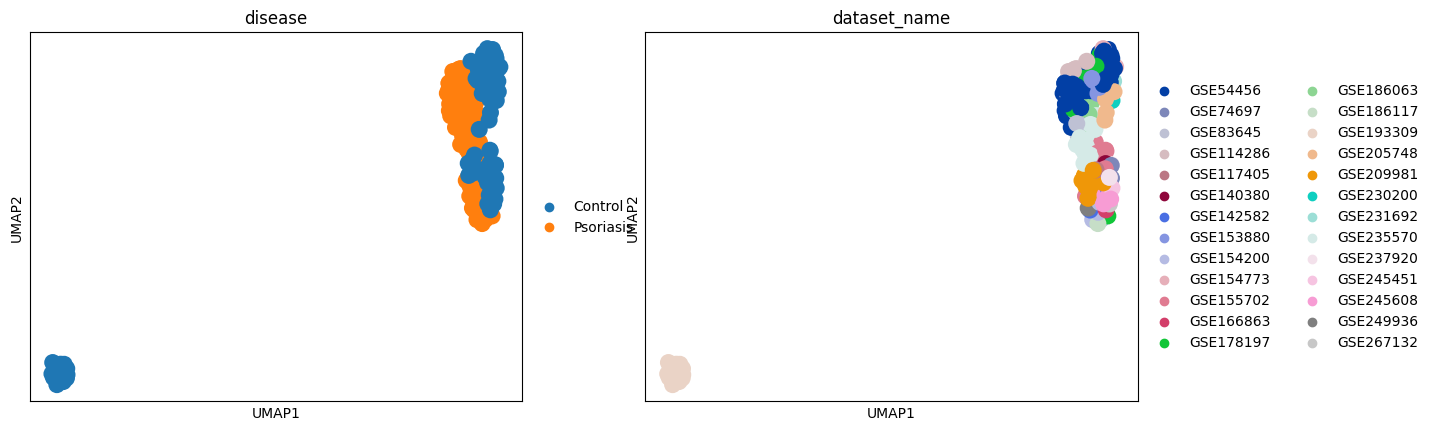

In [25]:
adata = zs_perturbation.load_dataset("PSO")

plot_embeddings(adata)

For the Dermatitis Atopic, the healthy samples shows a bimodal distribution (as well as the diseased ones). Therefore, the healthy centroid is less likely to make sense. We should consider both centroids.


/Users/quentinblampey/dev/zs_perturbation/zs_perturbation/io.py:23: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3")


Encoding:   0%|          | 0/8 [00:00<?, ?it/s]

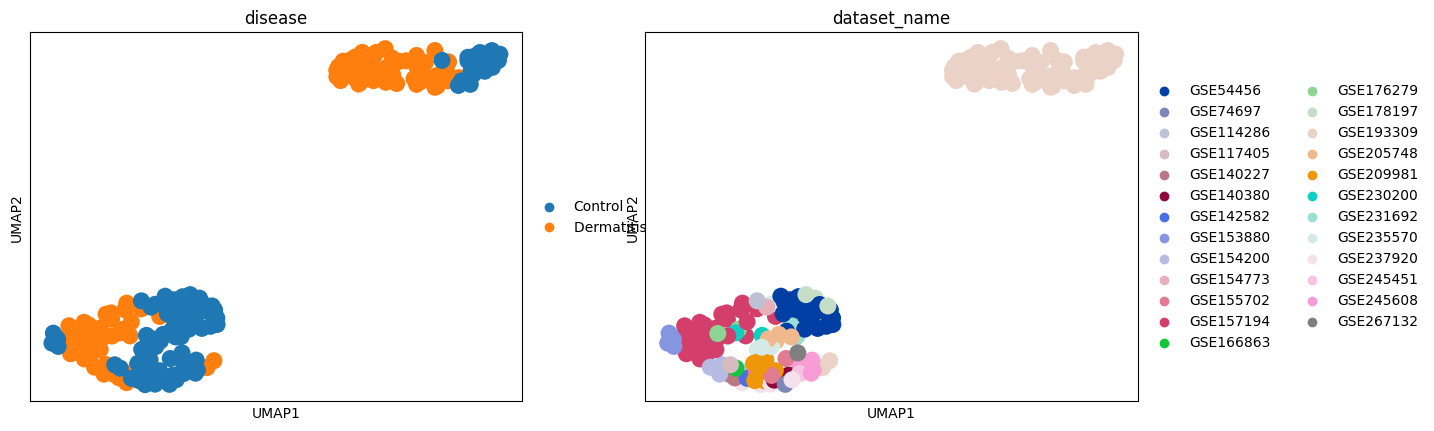

In [27]:
adata = zs_perturbation.load_dataset("AD")

plot_embeddings(adata)